# Flat tori with ShapeComp

Short illustration of the `shapecomp` package on **flat (planar) tori**:

1. Build parallelogram fundamental domains as triangle meshes
2. Subdivide with `shapecomp.subdivide_mesh`
3. Compare Teichmüller / hyperbolic distances between a domain–codomain pair
4. Run a short Euclidean area+shape optimization (near-identity and a stretched pair)

Requires an installed `shapecomp` (sibling editable install is fine) and the `tori-comparison` package.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import shapecomp as sc
import torch

# Allow importing run_flat_torus.py when the kernel cwd is the repo root.
EXPERIMENTS_DIR = Path.cwd()
if EXPERIMENTS_DIR.name != "experiments":
    candidate = EXPERIMENTS_DIR / "experiments"
    if candidate.is_dir():
        sys.path.insert(0, str(candidate))
        EXPERIMENTS_DIR = candidate
    else:
        sys.path.insert(0, str(EXPERIMENTS_DIR))

from run_flat_torus import (  # noqa: E402
    construct_planar_tori_domain_and_codomain_meshes,
    run_flat_torus_optimization,
)

print("shapecomp:", sc.__name__)
print("torch:", torch.__version__)
print("numpy:", np.__version__)
print("cwd:", Path.cwd())

shapecomp: shapecomp
torch: 2.14.0+cpu
numpy: 2.5.3
cwd: /home/yluo/Documents/tori-comparison/experiments


## 1. ShapeComp mesh API on a flat parallelogram

A flat torus is represented by a parallelogram spanned by `v1`, `v2`. We build a 2-triangle mesh with `sc.load_mesh(V, F)` and refine it with `sc.subdivide_mesh`.

coarse: (4, 3) (2, 3)
1× bary: (11, 3) (12, 3)
2× bary: (45, 3) (72, 3)


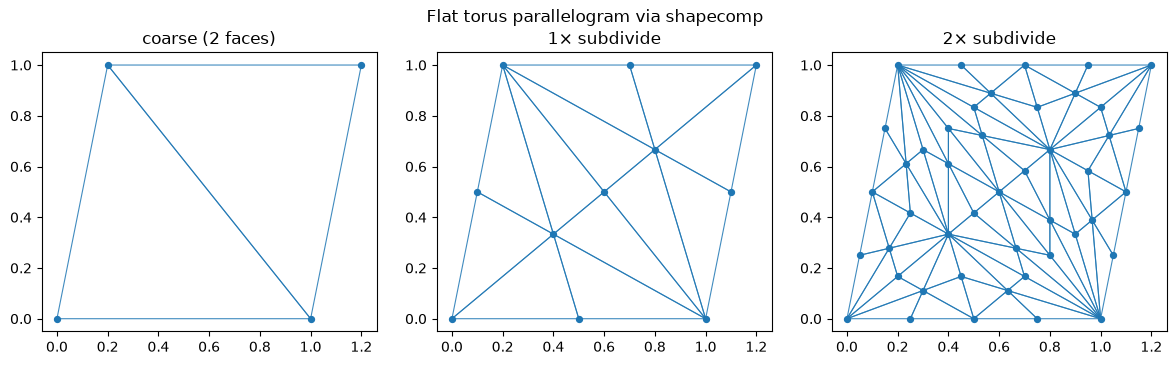

In [2]:
def parallelogram_mesh(v1: np.ndarray, v2: np.ndarray):
    """Return vertices/faces for the parallelogram [0, v1, v2, v1+v2]."""
    origin = np.array([0.0, 0.0, 0.0])
    v1 = np.asarray(v1, dtype=float)
    v2 = np.asarray(v2, dtype=float)
    v3 = origin + v1 + v2
    V = np.array([origin, v1, v2, v3])
    F = np.array([[0, 1, 2], [1, 3, 2]], dtype=np.int32)
    return V, F


def plot_mesh_2d(ax, V, F, *, color="C0", label=None, linewidth=0.8):
    V2 = np.asarray(V)[:, :2]
    for face in np.asarray(F):
        tri = V2[face]
        tri = np.vstack([tri, tri[0]])
        ax.plot(tri[:, 0], tri[:, 1], color=color, linewidth=linewidth, alpha=0.85)
    ax.scatter(V2[:, 0], V2[:, 1], s=18, color=color, label=label, zorder=3)
    ax.set_aspect("equal", adjustable="box")


v1 = np.array([1.0, 0.0, 0.0])
v2 = np.array([0.2, 1.0, 0.0])
V0, F0 = parallelogram_mesh(v1, v2)

mesh0 = sc.load_mesh(V0, F0, normalize=False)
mesh1 = sc.subdivide_mesh(mesh0)
mesh2 = sc.subdivide_mesh(mesh1)

print("coarse:", mesh0.get_vertices().shape, mesh0.get_faces().shape)
print("1× bary:", mesh1.get_vertices().shape, mesh1.get_faces().shape)
print("2× bary:", mesh2.get_vertices().shape, mesh2.get_faces().shape)
assert mesh0.get_vertices().shape[1] == mesh0.get_faces().shape[1] == 3

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, mesh, title in zip(
    axes,
    [mesh0, mesh1, mesh2],
    ["coarse (2 faces)", "1× subdivide", "2× subdivide"],
):
    plot_mesh_2d(ax, mesh.get_vertices(), mesh.get_faces(), color="C0")
    ax.set_title(title)
fig.suptitle("Flat torus parallelogram via shapecomp")
fig.tight_layout()
plt.show()

## 2. Domain / codomain pair and distances

Reuse the helpers from `run_flat_torus.py` (built on `shapecomp`) to construct a subdivided domain and report Teichmüller / hyperbolic distances to a codomain parallelogram.

domain mesh:    V=(45, 3), F=(72, 3)
L1 (domain):
[[1. 0.]
 [0. 1.]]
L2 (codomain):
[[1.  1. ]
 [0.  0.1]]
Teichmüller distance: 1.499118
hyperbolic distance:  2.998235


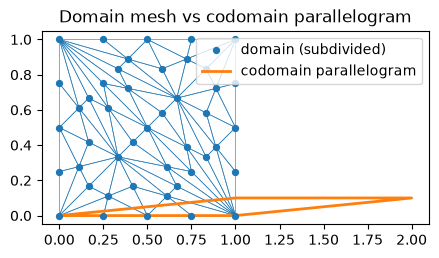

In [3]:
# Same lattice vectors used in flat_torus_comp.py
FLAT_TORUS_VECTORS = np.array(
    [
        [0.0, 1.0, 0.0],
        [1.0, 10.0, 0.0],
        [1.0, 0.1, 0.0],
        [-1.0, 10.0, 0.0],
        [-1.0, 0.1, 0.0],
    ]
)

domain_v1 = np.array([1.0, 0.0, 0.0])
domain_v2 = FLAT_TORUS_VECTORS[0]  # square-ish
codomain_v1 = np.array([1.0, 0.0, 0.0])
codomain_v2 = FLAT_TORUS_VECTORS[2]  # stretched

(
    V_domain,
    F_domain,
    L1,
    L2,
    teichmuller_distance,
    hyperbolic_dist,
    V_codomain,
    F_codomain,
) = construct_planar_tori_domain_and_codomain_meshes(
    domain_v1, domain_v2, codomain_v1, codomain_v2
)

print(f"domain mesh:    V={V_domain.shape}, F={F_domain.shape}")
print(f"L1 (domain):\n{L1}")
print(f"L2 (codomain):\n{L2}")
print(f"Teichmüller distance: {teichmuller_distance:.6f}")
print(f"hyperbolic distance:  {hyperbolic_dist:.6f}")

fig, ax = plt.subplots(figsize=(5, 5))
plot_mesh_2d(
    ax, V_domain, F_domain, color="C0", label="domain (subdivided)", linewidth=0.5
)
# Codomain coarse parallelogram outline
Vc = V_codomain[:, :2]
order = [0, 1, 3, 2, 0]
ax.plot(Vc[order, 0], Vc[order, 1], "C1-", linewidth=2, label="codomain parallelogram")
ax.legend(loc="best")
ax.set_title("Domain mesh vs codomain parallelogram")
plt.show()

## 3. Short Euclidean optimization smoke

Optimize a map between flat tori with a **small** iteration budget. Boundary vertex groups (`shared_inds`) keep identified edges consistent on the cut surface.

- **Case A:** domain == codomain (energy should drop near 0)
- **Case B:** stretched pair from above (positive Teichmüller distance)

In [19]:
def identity_initial_map(x: np.ndarray) -> np.ndarray:
    return np.asarray(x, dtype=float)


def non_identity_initial_map(x: np.ndarray) -> np.ndarray:
    """Mild non-identity start on the unit square."""
    return np.array([1 - (1 - x[0]) ** 2, 1 - (1 - x[1]) ** 2])


# Identification groups for the 2×-subdivided parallelogram used by flat_torus_comp.
SHARED_INDS = [
    [0, 1, 2, 3],
    [4, 8],
    [6, 7],
    [11, 20],
    [12, 19],
    [15, 18],
    [16, 17],
]

N_ITERS = 2000  # demo budget; flat_torus_comp.py uses far more
LR = 1e-3


def run_case(name, domain_v2, codomain_v2, initial_map):
    (
        Vd,
        Fd,
        L1_,
        L2_,
        teich,
        hyp,
        _Vc,
        _Fc,
    ) = construct_planar_tori_domain_and_codomain_meshes(
        np.array([1.0, 0.0, 0.0]),
        domain_v2,
        np.array([1.0, 0.0, 0.0]),
        codomain_v2,
    )
    (
        uv_traj,
        area_rec,
        shape_rec,
        loss_rec,
        best_energy,
    ) = run_flat_torus_optimization(
        Vd,
        Fd,
        SHARED_INDS,
        L1_,
        L2_,
        initial_map,
        approx_max_type="logsumexp",
        n_iterations=N_ITERS,
        learning_rate=LR,
        reduce_lr_on_plateau=True,
        reduce_lr_patience=100,
        energy_plateau_patience=None,  # always run full N_ITERS for the plot
    )
    print(
        f"[{name}] teich={teich:.4f}  hyp={hyp:.4f}  "
        f"final_area+shape={area_rec[-1] + shape_rec[-1]:.3e}  best={best_energy:.3e}"
    )
    return {
        "name": name,
        "teich": teich,
        "uv0": uv_traj[0],
        "uv1": uv_traj[-1],
        "faces": Fd,
        "area": np.asarray(area_rec),
        "shape": np.asarray(shape_rec),
        "loss": np.asarray(loss_rec),
        "best": best_energy,
    }


case = run_case(
    "stretched pair (warped init)",
    FLAT_TORUS_VECTORS[0],
    FLAT_TORUS_VECTORS[2],
    non_identity_initial_map,
)
cases = [case]

100%|██████████| 2000/2000 [00:01<00:00, 1200.12it/s]

[stretched pair (warped init)] teich=1.4991  hyp=2.9982  final_area+shape=2.197e+00  best=2.197e+00


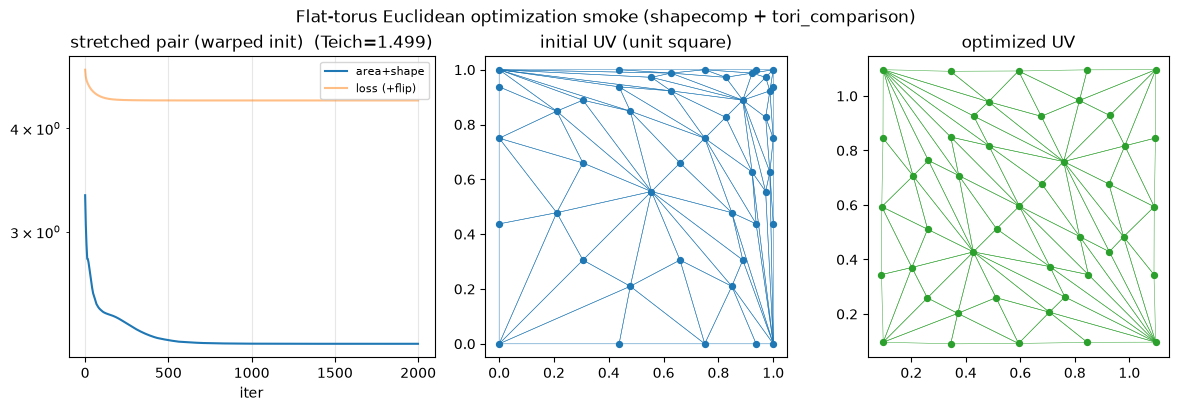

In [20]:
def _frame_uv(ax, V, pad=0.05):
    """Square window around the full mesh (torus maps may translate out of [0, 1])."""
    xy = np.asarray(V)[:, :2]
    lo, hi = xy.min(axis=0), xy.max(axis=0)
    span = max(*(hi - lo), 1.0)
    c = 0.5 * (lo + hi)
    ax.set_xlim(c[0] - span / 2 - pad, c[0] + span / 2 + pad)
    ax.set_ylim(c[1] - span / 2 - pad, c[1] + span / 2 + pad)


fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
ax_e, ax0, ax1 = axes
energy = case["area"] + case["shape"]
ax_e.semilogy(energy, label="area+shape")
ax_e.semilogy(case["loss"], alpha=0.5, label="loss (+flip)")
ax_e.set_title(f"{case['name']}  (Teich={case['teich']:.3f})")
ax_e.set_xlabel("iter")
ax_e.legend(fontsize=8)
ax_e.grid(True, alpha=0.3)

plot_mesh_2d(ax0, case["uv0"], case["faces"], color="C0", linewidth=0.4)
ax0.set_title("initial UV (unit square)")
_frame_uv(ax0, case["uv0"])

plot_mesh_2d(ax1, case["uv1"], case["faces"], color="C2", linewidth=0.4)
ax1.set_title("optimized UV")
_frame_uv(ax1, case["uv1"])

fig.suptitle("Flat-torus Euclidean optimization smoke (shapecomp + tori_comparison)")
plt.show()

## Notes

- Mesh construction and subdivision are pure **ShapeComp** (`load_mesh`, `subdivide_mesh`).
- Energies / optimization live in **tori-comparison** (`tori_comparison.energy`, `par_euc`, and `run_flat_torus`).
- For the full 10×10 matrix experiment see `flat_torus_comp.py` (much longer).
- Geodesic (surface) comparisons use `PlanarLocator` + tracked meshes under `data/fixtures/` / `experiments/smoke.yaml` instead of flat parallelograms.